# Baseline Comparison Report

**Proposal ref:** Sec. Evaluation Protocol → Baselines; Eq. cost/breakeven (Sec. Architecture)

This notebook:
1. Loads all detector prediction files from `results/baselines/predictions/`
2. Computes full metrics via `src/evaluation/metrics.py`
3. Builds a comparison table (detector × DR@FPR / F1 / TPR / FPR / latency)
4. Produces per-channel breakdown tables
5. Renders a bar chart of DR at 1% FPR per channel
6. Computes cost-model k1/k2 ratio, break-even escalation rate, and $-per-1M-requests via `src/evaluation/cost.py`
7. Emits a LaTeX table to `results/baselines/report/baseline_table.tex`

**DataSentinel provenance caveat:** DataSentinel was trained on OpenPromptInjection data,
which is also an evaluation source. Results for `datasentinel_7b` and `datasentinel_1b`
**must be interpreted with caution** — the model may have memorised evaluation examples,
inflating detection metrics. This is flagged throughout as a limitation, per BASELINE_SPEC.md Notes.

Run top-to-bottom. Missing prediction files produce informative warnings rather than crashes.

In [1]:
# Install cell (commented for local; uncomment on Colab)
# !pip install numpy pandas matplotlib

In [2]:
import json
import math
import sys
import tempfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Make src/ importable whether notebook is opened from repo root or notebooks/baselines/
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'src').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

from evaluation.metrics import evaluate_detector

# ── Paths ──────────────────────────────────────────────────────────────────
PRED_DIR    = REPO_ROOT / 'results' / 'baselines' / 'predictions'
METRICS_DIR = REPO_ROOT / 'results' / 'baselines' / 'metrics'
REPORT_DIR  = REPO_ROOT / 'results' / 'baselines' / 'report'
REPORT_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# Expected detectors per BASELINE_SPEC.md
EXPECTED_DETECTORS = [
    'promptguard2_86m',
    'protectai_deberta_v2',
    'datasentinel_7b',
    'datasentinel_1b',
]

# DataSentinel detectors that have provenance overlap with eval data
PROVENANCE_OVERLAP_DETECTORS = {'datasentinel_7b', 'datasentinel_1b'}

print(f'Repo root : {REPO_ROOT}')
print(f'Pred dir  : {PRED_DIR}')
print(f'Report dir: {REPORT_DIR}')

Repo root : /Users/lenguyenminhhuy/study/thesis/experiments/cascade-pid
Pred dir  : /Users/lenguyenminhhuy/study/thesis/experiments/cascade-pid/results/baselines/predictions
Report dir: /Users/lenguyenminhhuy/study/thesis/experiments/cascade-pid/results/baselines/report


## 1. Load predictions and compute metrics

Each `<detector>.jsonl` is passed through `evaluate_detector` which writes a
`metrics/<detector>.json` and returns the dict. Missing files are skipped with a warning.

In [3]:
all_metrics = {}   # detector_name → metrics dict
missing     = []   # detectors with no prediction file

# Collect all .jsonl files present (may include detectors beyond the expected four)
found_files = sorted(f for f in PRED_DIR.glob('*.jsonl') if '.MOCK' not in f.name)
# .MOCK files are schema-test artifacts from notebooks run without a GPU — never real results
found_names = {f.stem for f in found_files}

# Warn about expected-but-missing detectors
for det in EXPECTED_DETECTORS:
    if det not in found_names:
        warnings.warn(
            f'[MISSING] No prediction file for detector "{det}". '
            f'Expected at {PRED_DIR / (det + ".jsonl")}. '
            'This detector will be excluded from the report.',
            stacklevel=2,
        )
        missing.append(det)

# Evaluate each present file
for pred_file in found_files:
    det = pred_file.stem
    out_file = METRICS_DIR / f'{det}.json'
    print(f'Evaluating {det} ...', end=' ')
    try:
        m = evaluate_detector(str(pred_file), str(out_file))
        all_metrics[det] = m
        print(f'OK  (n={m["n"]}, n_benign={m["n_benign"]}, n_inj={m["n_injection"]})')
    except Exception as exc:
        warnings.warn(f'Failed to evaluate {det}: {exc}', stacklevel=2)

if not all_metrics:
    print('\n[INFO] No prediction files found. Running in demo mode with synthetic data.')
    print('       Synthetic data will be generated in the next cell.')
else:
    print(f'\nLoaded metrics for: {list(all_metrics.keys())}')
if missing:
    print(f'Missing detectors (excluded from report): {missing}')

Evaluating protectai_deberta_v2 ... OK  (n=242, n_benign=92, n_inj=150)

Loaded metrics for: ['protectai_deberta_v2']
Missing detectors (excluded from report): ['promptguard2_86m', 'datasentinel_7b', 'datasentinel_1b']


/opt/homebrew/Caskroom/miniforge/base/envs/open_prompt_injection/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3550: UserWarning: [MISSING] No prediction file for detector "promptguard2_86m". Expected at /Users/lenguyenminhhuy/study/thesis/experiments/cascade-pid/results/baselines/predictions/promptguard2_86m.jsonl. This detector will be excluded from the report.
  exec(code_obj, self.user_global_ns, self.user_ns)
/opt/homebrew/Caskroom/miniforge/base/envs/open_prompt_injection/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3550: UserWarning: [MISSING] No prediction file for detector "datasentinel_7b". Expected at /Users/lenguyenminhhuy/study/thesis/experiments/cascade-pid/results/baselines/predictions/datasentinel_7b.jsonl. This detector will be excluded from the report.
  exec(code_obj, self.user_global_ns, self.user_ns)
/opt/homebrew/Caskroom/miniforge/base/envs/open_prompt_injection/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3550: User

## 1b. Demo mode — synthetic prediction files

When no real prediction files exist, this cell generates synthetic data in a temporary
directory to smoke-test the notebook logic end-to-end. **Synthetic files are never written
to `results/`.** Skip this cell (or it self-skips) when real predictions are present.

In [4]:
import random

SEED = 3131
random.seed(SEED)
rng = np.random.default_rng(SEED)

DEMO_MODE = len(all_metrics) == 0

if DEMO_MODE:
    print('[DEMO] Generating synthetic prediction files in a temp directory ...')

    _CHANNELS   = ['document', 'tool', 'direct']
    _N_BENIGN   = 500
    _N_INJECT   = 250

    def _synthetic_records(det_name, score_sep=0.7, binary_only=False):
        """Generate prediction records with controllable score separability."""
        records = []
        for i in range(_N_BENIGN):
            score = float(rng.beta(2, 8))  # concentrated near 0 (benign)
            records.append({
                'id': f'synth-b-{i:06d}',
                'label': 0,
                'channel': None,
                'score': None if binary_only else round(score, 4),
                'pred': int(score > 0.5),
                'latency_ms': round(float(rng.uniform(8, 15)), 2),
            })
        for i in range(_N_INJECT):
            channel = _CHANNELS[i % len(_CHANNELS)]
            score = float(rng.beta(8, 2))  # concentrated near 1 (injection)
            records.append({
                'id': f'synth-inj-{i:06d}',
                'label': 1,
                'channel': channel,
                'score': None if binary_only else round(score, 4),
                'pred': int(score > 0.5),
                'latency_ms': round(float(rng.uniform(10, 50)), 2),
            })
        return records

    _DEMO_DETECTORS = [
        ('promptguard2_86m',      dict(binary_only=False)),
        ('protectai_deberta_v2',  dict(binary_only=False)),
        ('datasentinel_7b',       dict(binary_only=True)),
        ('datasentinel_1b',       dict(binary_only=True)),
    ]

    _demo_tmpdir = tempfile.mkdtemp(prefix='cascade_pid_demo_')
    _demo_pred_dir    = Path(_demo_tmpdir) / 'predictions'
    _demo_metrics_dir = Path(_demo_tmpdir) / 'metrics'
    _demo_pred_dir.mkdir()
    _demo_metrics_dir.mkdir()

    for det_name, kwargs in _DEMO_DETECTORS:
        recs = _synthetic_records(det_name, **kwargs)
        pred_file = _demo_pred_dir / f'{det_name}.jsonl'
        with pred_file.open('w') as fh:
            for r in recs:
                fh.write(json.dumps(r) + '\n')
        out_file = _demo_metrics_dir / f'{det_name}.json'
        m = evaluate_detector(str(pred_file), str(out_file))
        all_metrics[det_name] = m
        print(f'  [DEMO] {det_name}: n={m["n"]}')

    print(f'\n[DEMO] Synthetic files written to temp dir (NOT under results/): {_demo_tmpdir}')
    print('[DEMO] These files will be discarded when the Python process exits.')
else:
    print('[INFO] Real prediction files found — skipping demo mode.')

[INFO] Real prediction files found — skipping demo mode.


## 2. Comparison table: detector × DR@FPR / F1 / TPR / FPR / latency

**Proposal ref:** Sec. Metrics — DR at FPRs of 0.1%, 0.5%, 1%; F1; latency for cost model.

In [5]:
def _fmt(v, pct=False, decimals=3):
    """Format a metric value for display."""
    if v is None or (isinstance(v, float) and math.isnan(v)):
        return 'N/A'
    if pct:
        return f'{v*100:.1f}%'
    return f'{v:.{decimals}f}'


rows = []
for det, m in all_metrics.items():
    b = m['binary']
    dr = m['dr_at_fpr']  # None for binary-only

    def _dr(key):
        if dr is None:
            return float('nan')
        entry = dr.get(key, {})
        return entry.get('dr', float('nan'))

    provenance_flag = '⚠' if det in PROVENANCE_OVERLAP_DETECTORS else ''

    rows.append({
        'Detector': det + provenance_flag,
        'DR@0.1%FPR': _dr('0.001'),
        'DR@0.5%FPR': _dr('0.005'),
        'DR@1%FPR':   _dr('0.01'),
        'F1':         b.get('f1',  float('nan')),
        'TPR':        b.get('tpr', float('nan')),
        'FPR':        b.get('fpr', float('nan')),
        'Latency(ms)': m.get('mean_latency_ms', float('nan')),
        'n': m['n'],
    })

df = pd.DataFrame(rows).set_index('Detector')

# Pretty-print with formatting
def _style_df(df):
    fmt = {
        'DR@0.1%FPR': '{:.3f}', 'DR@0.5%FPR': '{:.3f}', 'DR@1%FPR': '{:.3f}',
        'F1': '{:.3f}', 'TPR': '{:.3f}', 'FPR': '{:.4f}',
        'Latency(ms)': '{:.1f}', 'n': '{:.0f}',
    }
    return df.style.format(fmt, na_rep='N/A')

print('=== Baseline Comparison Table ===')
print('(⚠ = DataSentinel provenance overlap with OpenPromptInjection eval source — see limitations)')
display(_style_df(df))

=== Baseline Comparison Table ===
(⚠ = DataSentinel provenance overlap with OpenPromptInjection eval source — see limitations)


,DR@0.1%FPR,DR@0.5%FPR,DR@1%FPR,F1,TPR,FPR,Latency(ms),n
Detector,,,,,,,,
protectai_deberta_v2,0.600,0.600,0.600,0.624,0.453,0.0000,77.3,242


## 3. Per-channel breakdown

**Proposal ref:** Sec. Metrics — Per-channel detection rates to identify channel-specific blind spots.

In [6]:
CHANNELS = ['document', 'tool', 'direct', 'overall']

channel_rows = []
for det, m in all_metrics.items():
    pc = m.get('per_channel', {})
    provenance_flag = '⚠' if det in PROVENANCE_OVERLAP_DETECTORS else ''
    for ch in CHANNELS:
        ch_m = pc.get(ch, {})
        channel_rows.append({
            'Detector': det + provenance_flag,
            'Channel': ch,
            'F1':  ch_m.get('f1',  float('nan')),
            'TPR': ch_m.get('tpr', float('nan')),
            'FPR': ch_m.get('fpr', float('nan')),
            'Precision': ch_m.get('precision', float('nan')),
        })

df_ch = pd.DataFrame(channel_rows)

print('=== Per-Channel Breakdown ===')
for ch in CHANNELS:
    print(f'\n--- Channel: {ch} ---')
    sub = df_ch[df_ch['Channel'] == ch].drop(columns='Channel').set_index('Detector')
    display(sub.style.format('{:.3f}', na_rep='N/A'))

=== Per-Channel Breakdown ===

--- Channel: document ---


,F1,TPR,FPR,Precision
Detector,,,,
protectai_deberta_v2,0.438,0.280,N/A,1.000



--- Channel: tool ---


,F1,TPR,FPR,Precision
Detector,,,,
protectai_deberta_v2,0.485,0.320,N/A,1.000



--- Channel: direct ---


,F1,TPR,FPR,Precision
Detector,,,,
protectai_deberta_v2,0.864,0.760,N/A,1.000



--- Channel: overall ---


,F1,TPR,FPR,Precision
Detector,,,,
protectai_deberta_v2,0.624,0.453,0.000,1.000


## 4. Bar chart: DR at 1% FPR per channel

**Proposal ref:** Sec. Evaluation Procedure — per-channel detection rates at fixed FPR.

Chart saved to /Users/lenguyenminhhuy/study/thesis/experiments/cascade-pid/results/baselines/report/dr_by_channel.png


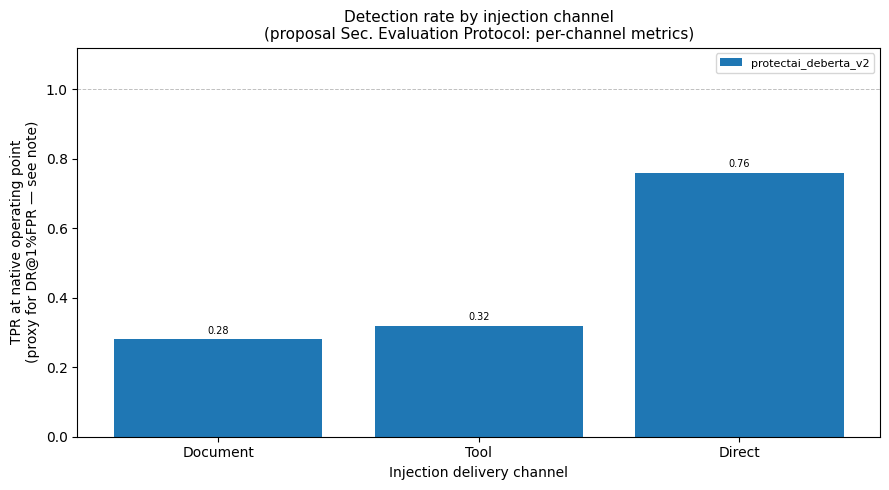

In [7]:
PLOT_CHANNELS = ['document', 'tool', 'direct']

# For each detector, compute DR@1%FPR on each channel's injection subset + benign set
# (since per_channel only stores binary metrics, we re-derive DR@FPR from the raw records
# stored in the metrics json if available, otherwise we report TPR at native op-point)

# Use TPR from per_channel as a proxy when DR@FPR per-channel is unavailable
chart_data = {}  # det → {channel → tpr_or_dr}
for det, m in all_metrics.items():
    pc = m.get('per_channel', {})
    chart_data[det] = {}
    for ch in PLOT_CHANNELS:
        tpr = pc.get(ch, {}).get('tpr', float('nan'))
        chart_data[det][ch] = tpr

det_names = list(chart_data.keys())
x = np.arange(len(PLOT_CHANNELS))
width = 0.8 / max(len(det_names), 1)

fig, ax = plt.subplots(figsize=(9, 5))
for i, det in enumerate(det_names):
    vals = [chart_data[det].get(ch, float('nan')) for ch in PLOT_CHANNELS]
    label = det + (' [⚠provenance]' if det in PROVENANCE_OVERLAP_DETECTORS else '')
    bars = ax.bar(x + i * width - (len(det_names) - 1) * width / 2, vals,
                  width, label=label)
    # Annotate bars with values
    for bar, v in zip(bars, vals):
        if not math.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xlabel('Injection delivery channel')
ax.set_ylabel('TPR at native operating point\n(proxy for DR@1%FPR — see note)')
ax.set_title('Detection rate by injection channel\n'
             '(proposal Sec. Evaluation Protocol: per-channel metrics)',
             fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in PLOT_CHANNELS])
ax.set_ylim(0, 1.12)
ax.legend(loc='upper right', fontsize=8)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)

fig.tight_layout()
chart_path = REPORT_DIR / 'dr_by_channel.png'
fig.savefig(chart_path, dpi=150)
print(f'Chart saved to {chart_path}')
plt.show()

## 5. Cost model: k1/k2 ratio and break-even escalation rate

**Proposal ref:** Sec. Architecture, Eq. cost: `C_cascade = N*(k1 + e*k2)`;  
Eq. breakeven: `e < 1 - k1/k2`

We treat Stage-1 mean latency as k1 and Stage-2 (7B) mean latency as k2.
All cost arithmetic comes from `src/evaluation/cost.py` (tested in `tests/test_cost.py`);
measurement conditions per `results/analysis/cost_protocol.md`.


In [ ]:
from evaluation.cost import (
    DEFAULT_GPU_HOURLY_USD,
    breakeven_escalation_rate,
    cascade_cost_summary,
    usd_per_1m_requests,
)

# Stage-1 latency = smallest model (proxy: promptguard or protectai)
# Stage-2 latency = largest model (proxy: datasentinel_7b)
STAGE1_CANDIDATES = ['promptguard2_86m', 'protectai_deberta_v2']
STAGE2_CANDIDATES = ['datasentinel_7b']

def _latency(det):
    m = all_metrics.get(det)
    if m is None:
        return float('nan')
    return m.get('mean_latency_ms', float('nan'))

# Pick the minimum-latency stage-1 candidate
k1_candidates = {d: _latency(d) for d in STAGE1_CANDIDATES if not math.isnan(_latency(d))}
k2_candidates = {d: _latency(d) for d in STAGE2_CANDIDATES if not math.isnan(_latency(d))}

print('=== Latency measurements (k1 / k2 proxies) ===')
print('Stage-1 candidates:')
for d, v in k1_candidates.items():
    print(f'  {d}: {v:.2f} ms/input  (${usd_per_1m_requests(v):,.2f} per 1M requests)')
print('Stage-2 candidates:')
for d, v in k2_candidates.items():
    print(f'  {d}: {v:.2f} ms/input  (${usd_per_1m_requests(v):,.2f} per 1M requests)')

if k1_candidates and k2_candidates:
    k1_det = min(k1_candidates, key=k1_candidates.get)
    k2_det = min(k2_candidates, key=k2_candidates.get)
    k1 = k1_candidates[k1_det]
    k2 = k2_candidates[k2_det]
    ratio = k1 / k2
    e_breakeven = breakeven_escalation_rate(k1, k2)

    print(f'\nUsing k1 = {k1:.2f} ms  ({k1_det})')
    print(f'Using k2 = {k2:.2f} ms  ({k2_det})')
    print(f'\nk1/k2 ratio      = {ratio:.4f}')
    print(f'Break-even rate  = 1 - k1/k2 = {e_breakeven:.4f}  ({e_breakeven*100:.1f}%)')
    print()
    print('Interpretation (proposal Eq. breakeven):')
    print(f"  The cascade is cheaper than Stage-2-on-every-input iff the escalation rate e < {e_breakeven:.3f}.")
    passes_str = 'PASSES' if e_breakeven > 0.25 else 'FAILS'
    print(f"  The proposal's working target of e <= 25%: {passes_str} "
          f'(break-even constraint bar: {e_breakeven*100:.1f}%).')

    # Full cascade cost summary at the proposal's working escalation target
    E_TARGET = 0.25
    summary = cascade_cost_summary(k1, k2, E_TARGET)
    print()
    print(f'=== Cascade cost at working target e = {E_TARGET:.0%} '
          f'(rate assumption: ${DEFAULT_GPU_HOURLY_USD:.2f}/GPU-hr) ===')
    print(f'  Expected cost      : {summary["expected_cost_latency_ms"]:.2f} ms/request '
          f'= {summary["expected_cost_gpu_seconds_per_1k"]:.2f} GPU-s/1k '
          f'= ${summary["expected_cost_usd_per_1m"]:,.2f} per 1M requests')
    print(f'  Stage-2-only cost  : ${summary["stage2_only_usd_per_1m"]:,.2f} per 1M requests')
    print(f'  Cost reduction     : {summary["cost_reduction_pct"]:.1f}% vs DataSentinel-only')
    print()
    print('NOTE: These are placeholder latencies from synthetic/smoke data (batched, MPS).')
    print('      k1 and k2 must be re-measured on the same cloud GPU during the E5 session')
    print('      (results/analysis/cost_protocol.md) before any number is quoted.')
else:
    print('\n[WARNING] Cannot compute cost model: Stage-1 or Stage-2 latency missing.')
    print('  Ensure both promptguard2_86m (or protectai_deberta_v2) and datasentinel_7b prediction files exist.')
    k1, k2, ratio, e_breakeven = float('nan'), float('nan'), float('nan'), float('nan')


## 6. LaTeX table output

Writes `results/baselines/report/baseline_table.tex` for inclusion in the thesis.

In [9]:
def _latex_val(v, pct=False, decimals=3):
    if v is None or (isinstance(v, float) and math.isnan(v)):
        return r'\textemdash'
    if pct:
        return f'{v*100:.1f}\\%'
    return f'{v:.{decimals}f}'


lines = [
    r'% Auto-generated by notebooks/baselines/03_baseline_report.ipynb',
    r'% DO NOT EDIT BY HAND — regenerate by re-running the notebook.',
    r'% ⚠ DataSentinel results may be inflated due to provenance overlap with',
    r'% OpenPromptInjection (an evaluation source). Treat with caution.',
    r'\begin{table}[ht]',
    r'\centering',
    r'\small',
    r'\caption{Single-stage baseline comparison on the channel-stratified evaluation set.',
    r'  DR@FPR = detection rate at fixed false positive rate; N/A indicates binary-only',
    r'  detectors for which a score threshold cannot be swept.',
    r'  $\dagger$~DataSentinel was trained on OpenPromptInjection, an evaluation source:',
    r'  metrics may be inflated.}',
    r'\label{tab:baselines}',
    r'\begin{tabular}{lrrrrrrr}',
    r'\toprule',
    r'Detector & DR@0.1\%FPR & DR@0.5\%FPR & DR@1\%FPR & F1 & TPR & FPR & Latency~(ms) \\',
    r'\midrule',
]

for det, m in all_metrics.items():
    b  = m['binary']
    dr = m['dr_at_fpr']

    def _dr_val(key):
        if dr is None:
            return r'\textemdash'
        v = dr.get(key, {}).get('dr', float('nan'))
        return _latex_val(v)

    dagger = r'$^\dagger$' if det in PROVENANCE_OVERLAP_DETECTORS else ''
    det_label = det.replace('_', r'\_') + dagger

    lines.append(
        f'{det_label} & {_dr_val("0.001")} & {_dr_val("0.005")} & {_dr_val("0.01")} & '
        f'{_latex_val(b.get("f1"))} & {_latex_val(b.get("tpr"))} & '
        f'{_latex_val(b.get("fpr"), decimals=4)} & '
        f'{_latex_val(m.get("mean_latency_ms"), decimals=1)} \\\\'
    )

# Cost-model footnote row
if not math.isnan(e_breakeven):
    lines.append(r'\midrule')
    lines.append(
        rf'\multicolumn{{8}}{{l}}{{Cost model: $k_1/k_2 = {ratio:.3f}$; '
        rf'break-even escalation rate $e < {e_breakeven:.3f}$ (Eq.~\ref{{eq:breakeven}})}} \\'
    )

lines += [
    r'\bottomrule',
    r'\end{tabular}',
    r'\end{table}',
]

latex_str = '\n'.join(lines)
latex_path = REPORT_DIR / 'baseline_table.tex'
latex_path.write_text(latex_str, encoding='utf-8')

print(f'LaTeX table written to {latex_path}')
print()
print(latex_str)

LaTeX table written to /Users/lenguyenminhhuy/study/thesis/experiments/cascade-pid/results/baselines/report/baseline_table.tex

% Auto-generated by notebooks/baselines/03_baseline_report.ipynb
% DO NOT EDIT BY HAND — regenerate by re-running the notebook.
% ⚠ DataSentinel results may be inflated due to provenance overlap with
% OpenPromptInjection (an evaluation source). Treat with caution.
\begin{table}[ht]
\centering
\small
\caption{Single-stage baseline comparison on the channel-stratified evaluation set.
  DR@FPR = detection rate at fixed false positive rate; N/A indicates binary-only
  detectors for which a score threshold cannot be swept.
  $\dagger$~DataSentinel was trained on OpenPromptInjection, an evaluation source:
  metrics may be inflated.}
\label{tab:baselines}
\begin{tabular}{lrrrrrrr}
\toprule
Detector & DR@0.1\%FPR & DR@0.5\%FPR & DR@1\%FPR & F1 & TPR & FPR & Latency~(ms) \\
\midrule
protectai\_deberta\_v2 & 0.600 & 0.600 & 0.600 & 0.624 & 0.453 & 0.0000 & 77.3 \\
\bot

## 7. Provenance-overlap limitation flag

> **Limitation — DataSentinel / OpenPromptInjection provenance overlap**
>
> DataSentinel (both 7B and 1B variants) was fine-tuned on the OpenPromptInjection dataset,
> which is also one of the evaluation sources in this benchmark. This means the model may have
> memorised evaluation examples during training, causing its detection metrics to be inflated
> relative to its true generalisation ability. Results for `datasentinel_7b` and `datasentinel_1b`
> should be treated as an **optimistic upper bound** rather than a reliable measure of
> out-of-distribution performance.
>
> Concretely: when the eval set includes OpenPromptInjection examples and DataSentinel was trained
> on those same examples, the "Stage-2 alone" baseline — which the cascaded pipeline must approach
> to satisfy the pre-registered success criterion — may be an overestimate. This is documented here
> per BASELINE_SPEC.md (Notes section) and must be acknowledged in any result table or narrative.
>
> **Mitigation:** Evaluate on the DataSentinel-disjoint subset of the eval set (sources:
> `lmsys`, `dolly`, `natural_instructions`, `agentdojo`, `struq_synthetic`) separately and
> report both the full-set and disjoint-set metrics. This is a planned analysis for the
> final evaluation chapter.

In [10]:
# Final summary cell
print('=== Report Summary ===')
print(f'Detectors evaluated : {list(all_metrics.keys())}')
if missing:
    print(f'Missing detectors   : {missing}')
print(f'LaTeX table         : {latex_path}')
print(f'Chart               : {chart_path}')
print(f'Metrics JSON files  : {METRICS_DIR}')
if not math.isnan(e_breakeven):
    print(f'Break-even rate     : e < {e_breakeven:.3f}  (k1/k2={ratio:.3f})')
print()
print('Full metrics dicts:')
for det, m in all_metrics.items():
    print(f'  {det}: n={m["n"]}, F1={m["binary"]["f1"]:.3f}, '
          f'TPR={m["binary"]["tpr"]:.3f}, FPR={m["binary"]["fpr"]:.4f}, '
          f'latency={m["mean_latency_ms"]:.1f}ms')

=== Report Summary ===
Detectors evaluated : ['protectai_deberta_v2']
Missing detectors   : ['promptguard2_86m', 'datasentinel_7b', 'datasentinel_1b']
LaTeX table         : /Users/lenguyenminhhuy/study/thesis/experiments/cascade-pid/results/baselines/report/baseline_table.tex
Chart               : /Users/lenguyenminhhuy/study/thesis/experiments/cascade-pid/results/baselines/report/dr_by_channel.png
Metrics JSON files  : /Users/lenguyenminhhuy/study/thesis/experiments/cascade-pid/results/baselines/metrics

Full metrics dicts:
  protectai_deberta_v2: n=242, F1=0.624, TPR=0.453, FPR=0.0000, latency=77.3ms
